In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv("Walmart.csv")

In [47]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [48]:
df.shape

(6435, 8)

In [49]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [51]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [54]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [55]:
df["Date"].head()

0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[ns]

In [56]:
df.isnull().sum()


Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [57]:
df["Weekly_Sales"].sum()

np.float64(6737218987.11)

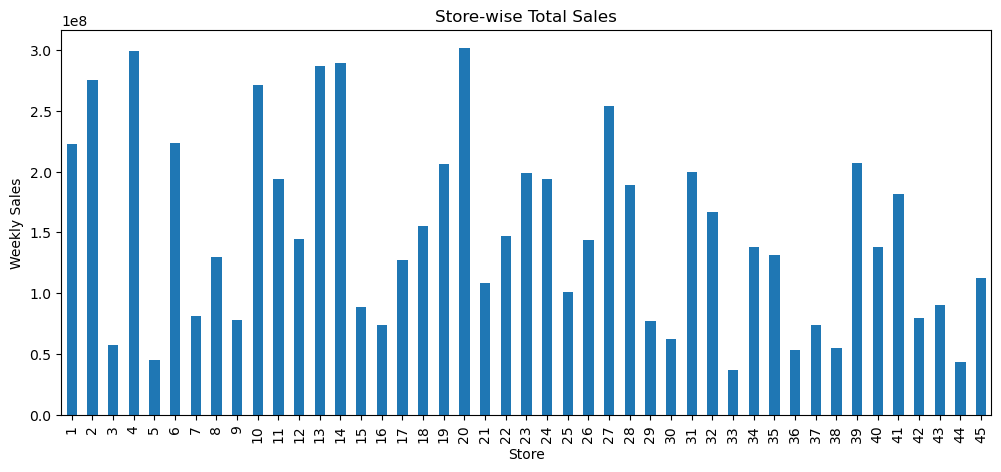

In [58]:
store_sales = df.groupby("Store")["Weekly_Sales"].sum()

plt.figure(figsize=(12,5))
store_sales.plot(kind="bar")
plt.title("Store-wise Total Sales")
plt.xlabel("Store")
plt.ylabel("Weekly Sales")
plt.show()

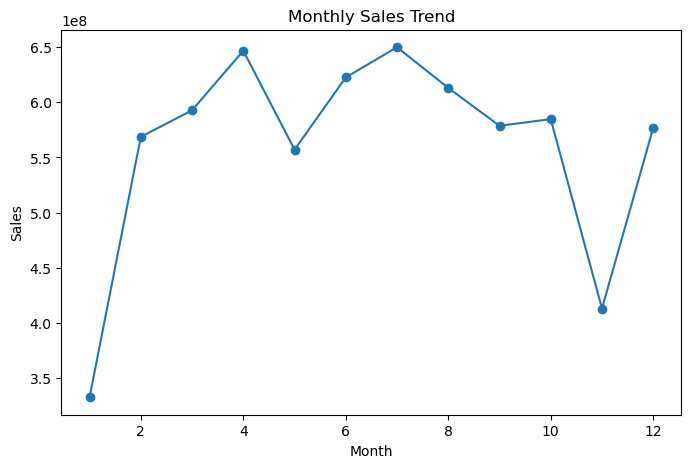

In [59]:
df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = df.groupby(df["Date"].dt.month)["Weekly_Sales"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

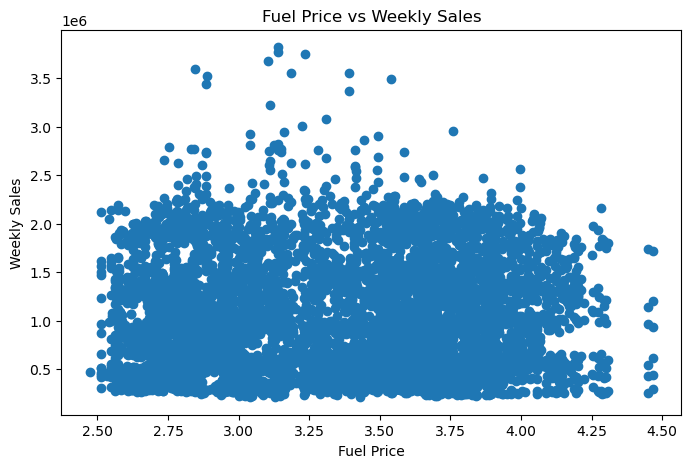

In [60]:
plt.figure(figsize=(8,5))
plt.scatter(df["Fuel_Price"], df["Weekly_Sales"])
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")
plt.title("Fuel Price vs Weekly Sales")
plt.show()

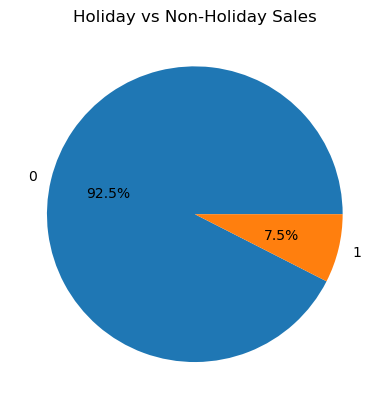

In [61]:
holiday_sales = df.groupby("Holiday_Flag")["Weekly_Sales"].sum()

holiday_sales.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

In [41]:
store_sales = df.groupby("Store")["Weekly_Sales"].sum()
store_sales

Store
1     2.224028e+08
2     2.753824e+08
3     5.758674e+07
4     2.995440e+08
5     4.547569e+07
6     2.237561e+08
7     8.159828e+07
8     1.299512e+08
9     7.778922e+07
10    2.716177e+08
11    1.939628e+08
12    1.442872e+08
13    2.865177e+08
14    2.889999e+08
15    8.913368e+07
16    7.425243e+07
17    1.277821e+08
18    1.551147e+08
19    2.066349e+08
20    3.013978e+08
21    1.081179e+08
22    1.470756e+08
23    1.987506e+08
24    1.940160e+08
25    1.010612e+08
26    1.434164e+08
27    2.538559e+08
28    1.892637e+08
29    7.714155e+07
30    6.271689e+07
31    1.996139e+08
32    1.668192e+08
33    3.716022e+07
34    1.382498e+08
35    1.315207e+08
36    5.341221e+07
37    7.420274e+07
38    5.515963e+07
39    2.074455e+08
40    1.378703e+08
41    1.813419e+08
42    7.956575e+07
43    9.056544e+07
44    4.329309e+07
45    1.123953e+08
Name: Weekly_Sales, dtype: float64

In [62]:
store_sales.idxmax()

np.int64(20)

In [63]:
store_sales.max()

301397792.46

In [64]:
 avg_store_sales = df.groupby("Store")["Weekly_Sales"].mean()

In [65]:
avg_store_sales

Store
1     1.555264e+06
2     1.925751e+06
3     4.027044e+05
4     2.094713e+06
5     3.180118e+05
6     1.564728e+06
7     5.706173e+05
8     9.087495e+05
9     5.439806e+05
10    1.899425e+06
11    1.356383e+06
12    1.009002e+06
13    2.003620e+06
14    2.020978e+06
15    6.233125e+05
16    5.192477e+05
17    8.935814e+05
18    1.084718e+06
19    1.444999e+06
20    2.107677e+06
21    7.560691e+05
22    1.028501e+06
23    1.389864e+06
24    1.356755e+06
25    7.067215e+05
26    1.002912e+06
27    1.775216e+06
28    1.323522e+06
29    5.394514e+05
30    4.385796e+05
31    1.395901e+06
32    1.166568e+06
33    2.598617e+05
34    9.667816e+05
35    9.197250e+05
36    3.735120e+05
37    5.189003e+05
38    3.857317e+05
39    1.450668e+06
40    9.641280e+05
41    1.268125e+06
42    5.564039e+05
43    6.333247e+05
44    3.027489e+05
45    7.859814e+05
Name: Weekly_Sales, dtype: float64

In [66]:
avg_store_sales.idxmax()

np.int64(20)

In [67]:
avg_store_sales.max()

2107676.8703496503

In [68]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

df["Month"] = df["Date"].dt.month

df.groupby("Month")["Weekly_Sales"].sum()

Month
1     3.325984e+08
2     5.687279e+08
3     5.927859e+08
4     6.468598e+08
5     5.571256e+08
6     6.226299e+08
7     6.500010e+08
8     6.130902e+08
9     5.787612e+08
10    5.847848e+08
11    4.130157e+08
12    5.768386e+08
Name: Weekly_Sales, dtype: float64

In [69]:
df.nlargest(5, "Weekly_Sales")

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month
1905,14,2010-12-24,3818686.45,0,30.59,3.141,182.544590,8.724,12
2763,20,2010-12-24,3766687.43,0,25.17,3.141,204.637673,7.484,12
1333,10,2010-12-24,3749057.69,0,57.06,3.236,126.983581,9.003,12
527,4,2011-12-23,3676388.98,0,35.92,3.103,129.984548,5.143,12
1762,13,2010-12-24,3595903.20,0,34.90,2.846,126.983581,7.795,12


In [70]:
df["Weekly_Sales"].head(5)

0    1643690.90
1    1641957.44
2    1611968.17
3    1409727.59
4    1554806.68
Name: Weekly_Sales, dtype: float64

In [71]:
df.nlargest(10,"Fuel_Price")

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month
1427,10,2012-10-12,1713889.11,0,76.03,4.468,131.108333,6.943,10
1713,12,2012-10-12,934917.47,0,71.74,4.468,131.108333,10.199,10
4001,28,2012-10-12,1205536.71,0,71.74,4.468,131.108333,10.199,10
4716,33,2012-10-12,291781.15,0,79.64,4.468,131.108333,6.895,10
5431,38,2012-10-12,437320.66,0,71.74,4.468,131.108333,10.199,10
6003,42,2012-10-12,612379.90,0,76.03,4.468,131.108333,6.943,10
1428,10,2012-10-19,1734834.82,0,72.71,4.449,131.149968,6.943,10
1714,12,2012-10-19,960945.43,0,68.66,4.449,131.149968,10.199,10
4002,28,2012-10-19,1143724.48,0,68.66,4.449,131.149968,10.199,10
4717,33,2012-10-19,254412.34,0,75.55,4.449,131.149968,6.895,10


In [72]:
df.nlargest(5, "Weekly_Sales")

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month
1905,14,2010-12-24,3818686.45,0,30.59,3.141,182.544590,8.724,12
2763,20,2010-12-24,3766687.43,0,25.17,3.141,204.637673,7.484,12
1333,10,2010-12-24,3749057.69,0,57.06,3.236,126.983581,9.003,12
527,4,2011-12-23,3676388.98,0,35.92,3.103,129.984548,5.143,12
1762,13,2010-12-24,3595903.20,0,34.90,2.846,126.983581,7.795,12


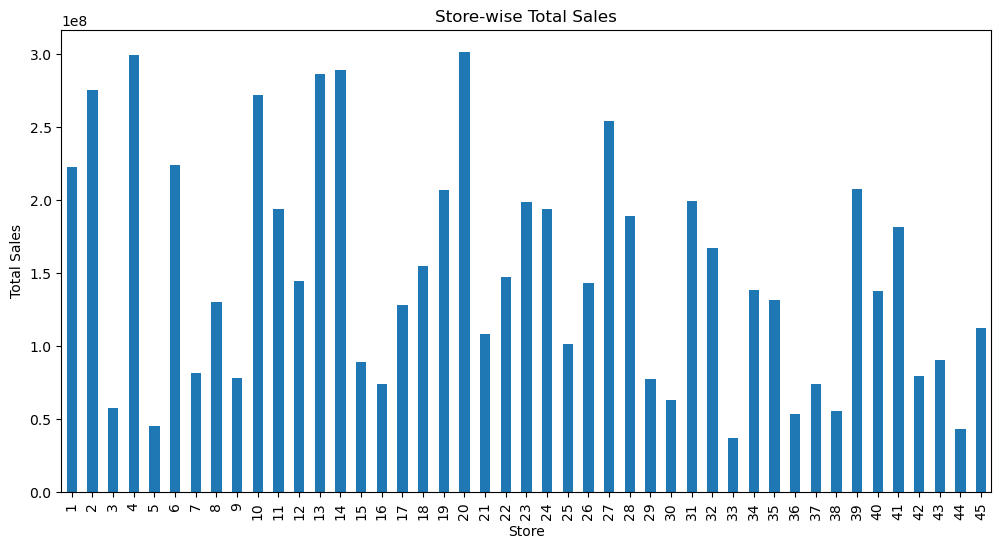

In [73]:
import matplotlib.pyplot as plt

store_sales = df.groupby("Store")["Weekly_Sales"].sum()

plt.figure(figsize=(12,6))
store_sales.plot(kind="bar")
plt.title("Store-wise Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

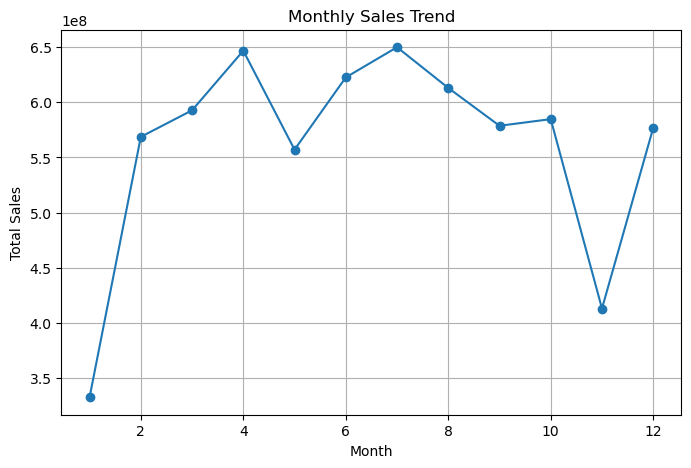

In [74]:
df["Month"] = df["Date"].dt.month

monthly_sales = df.groupby("Month")["Weekly_Sales"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

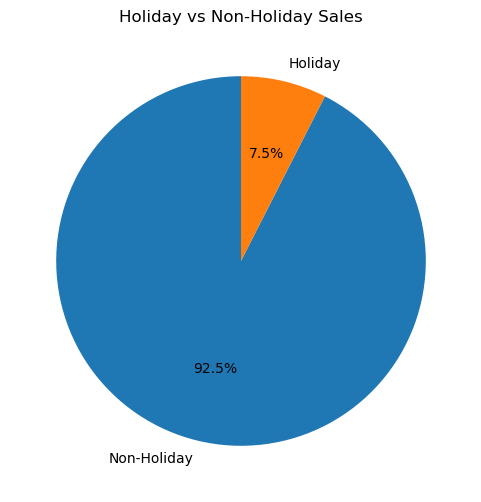

In [75]:
holiday_sales = df.groupby("Holiday_Flag")["Weekly_Sales"].sum()

plt.figure(figsize=(6,6))
plt.pie(
    holiday_sales,
    labels=["Non-Holiday", "Holiday"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

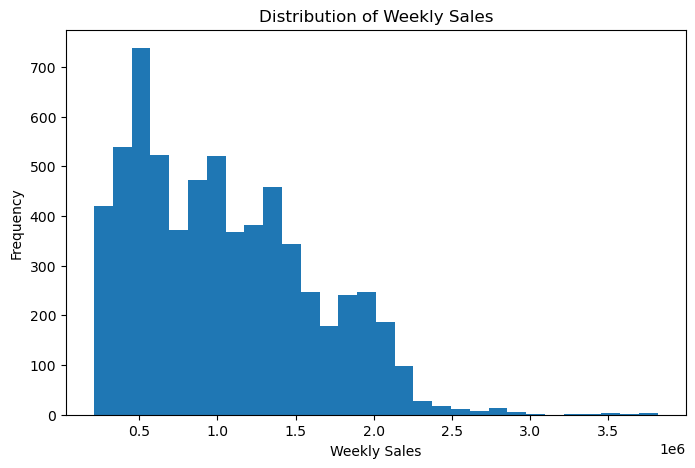

In [76]:
plt.figure(figsize=(8,5))
plt.hist(df["Weekly_Sales"], bins=30)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

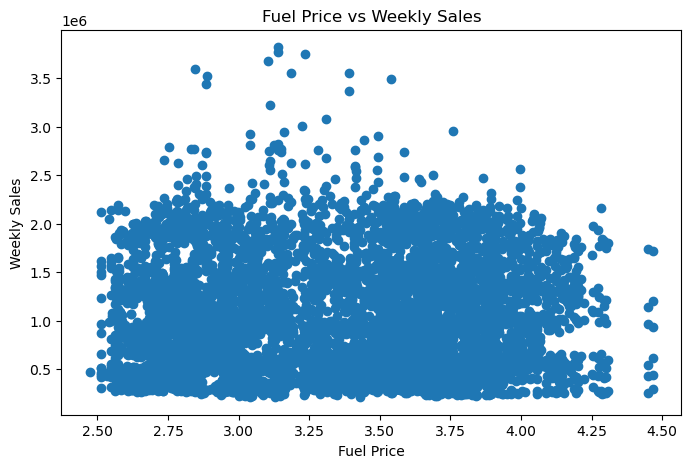

In [77]:
plt.figure(figsize=(8,5))
plt.scatter(df["Fuel_Price"], df["Weekly_Sales"])
plt.title("Fuel Price vs Weekly Sales")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")
plt.show()

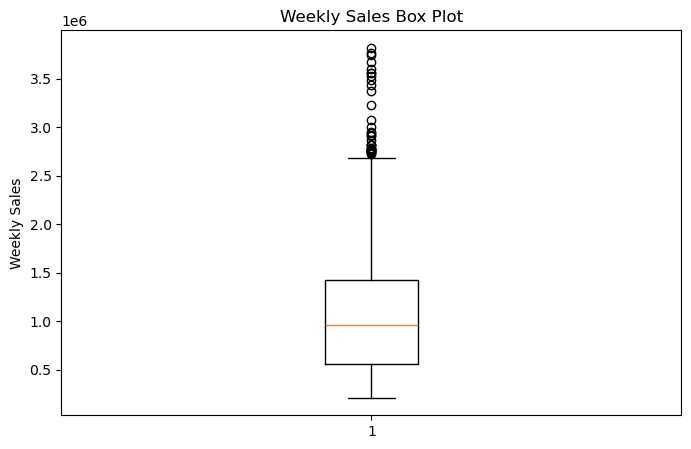

In [78]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Weekly_Sales"])
plt.title("Weekly Sales Box Plot")
plt.ylabel("Weekly Sales")
plt.show()

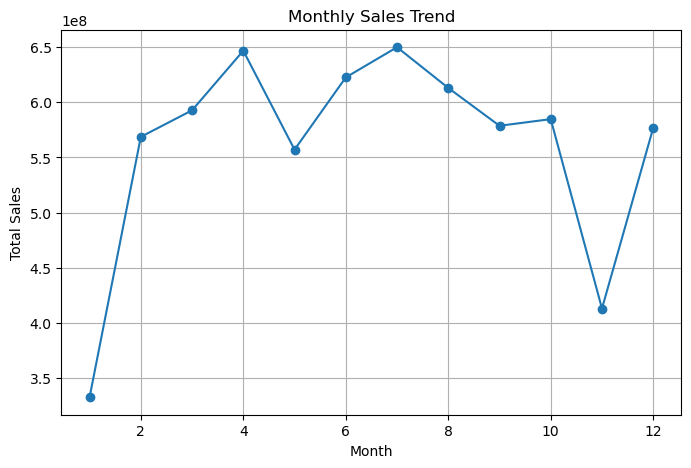

In [79]:
df["Month"] = df["Date"].dt.month

monthly_sales = df.groupby("Month")["Weekly_Sales"].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()